In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:

# Load cleaned dataset
df = pd.read_csv("../data/processed/clean_air_quality.csv", index_col='Datetime', parse_dates=True)

In [4]:
# Summary Statistics
print("Dataset Overview:")
print(df.describe())


Dataset Overview:
       PM10 (μg/m³)  PM2.5 (μg/m³)    CO (μg/m³)   NO2 (μg/m³)   SO2 (μg/m³)  \
count  11803.000000   11803.000000  11803.000000  11803.000000  11803.000000   
mean       0.412421       0.417770      0.380569      0.306446      0.415350   
std        0.195012       0.192610      0.202881      0.243577      0.192347   
min        0.000000       0.000000      0.000000      0.000000      0.000000   
25%        0.270415       0.278884      0.215789      0.100917      0.259259   
50%        0.384203       0.390438      0.327273      0.250765      0.398148   
75%        0.534137       0.537849      0.516746      0.449541      0.546296   
max        1.000000       1.000000      1.000000      1.000000      1.000000   

        O3  (μg/m³)     Temp (°C)  Humidity (%)  Wind_Speed (km/h)  \
count  11803.000000  11803.000000  11803.000000       11803.000000   
mean       0.490407      0.555378      0.722355           0.408089   
std        0.196093      0.197847      0.235653    

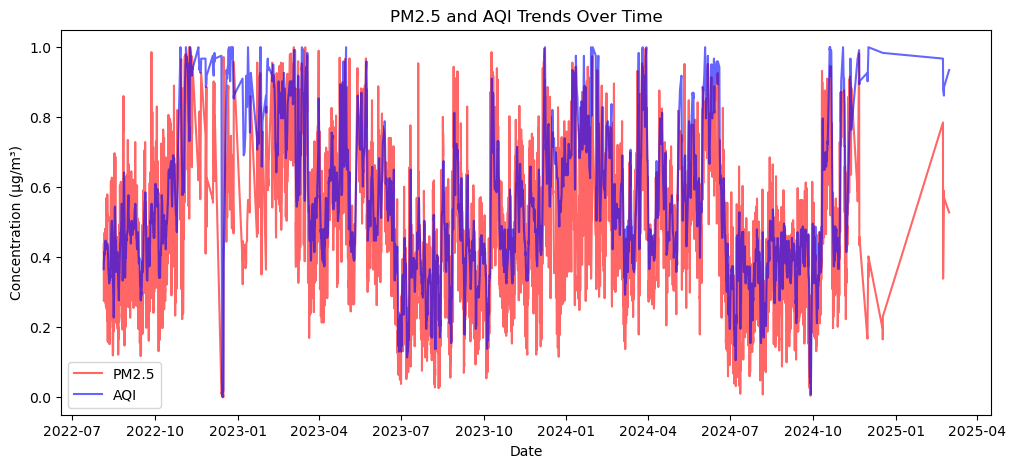

In [13]:

#Time-Series Trends for PM2.5 and AQI
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['PM2.5 (μg/m³)'], label='PM2.5', color='red', alpha=0.6)
plt.plot(df.index, df['AQI'], label='AQI', color='blue', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Concentration (μg/m³)")
plt.title("PM2.5 and AQI Trends Over Time")
plt.legend()
plt.savefig("../reports/figures/pm25_aqi_trends.png")
plt.show()

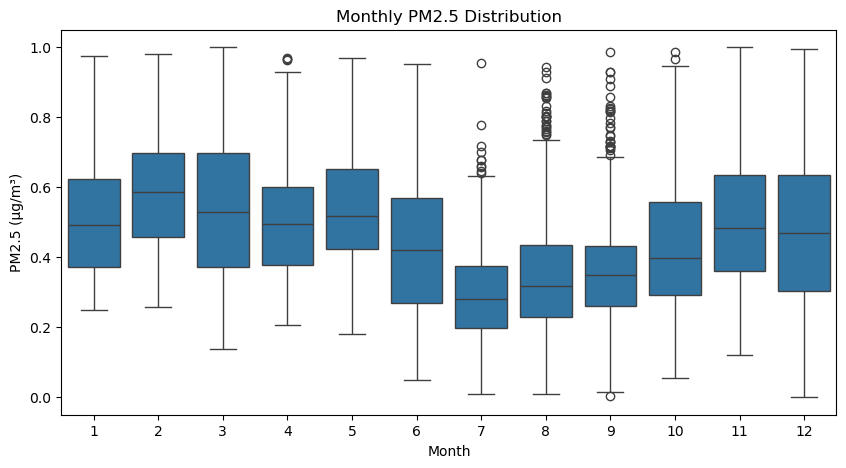

In [14]:
# Seasonality Analysis (Daily, Monthly)
df['Month'] = df.index.month
df['Hour'] = df.index.hour
plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='PM2.5 (μg/m³)', data=df)
plt.title("Monthly PM2.5 Distribution")
plt.savefig("../reports/figures/monthly_pm25.png")
plt.show()


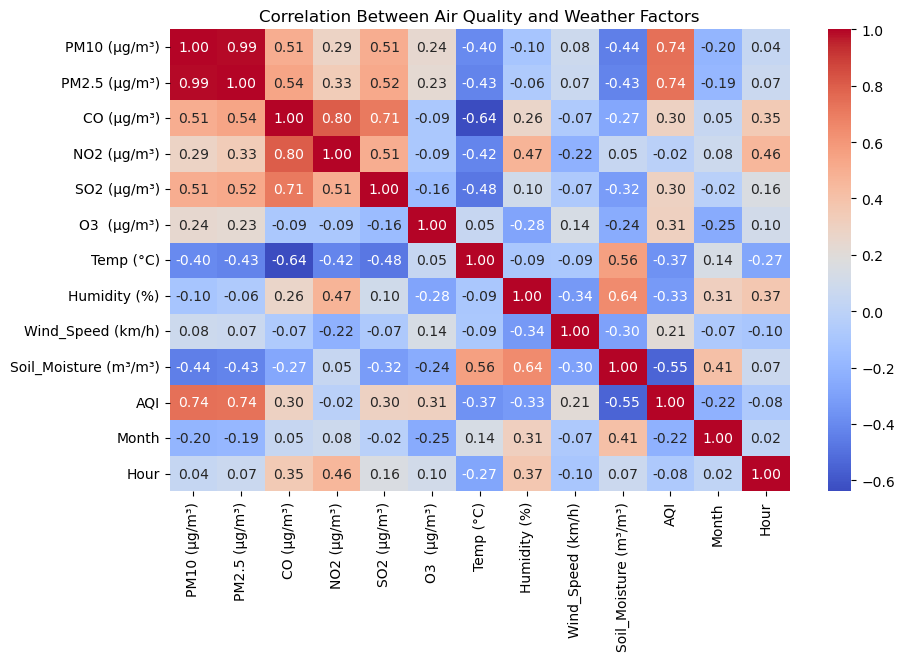

In [15]:
#Correlation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Air Quality and Weather Factors")
plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

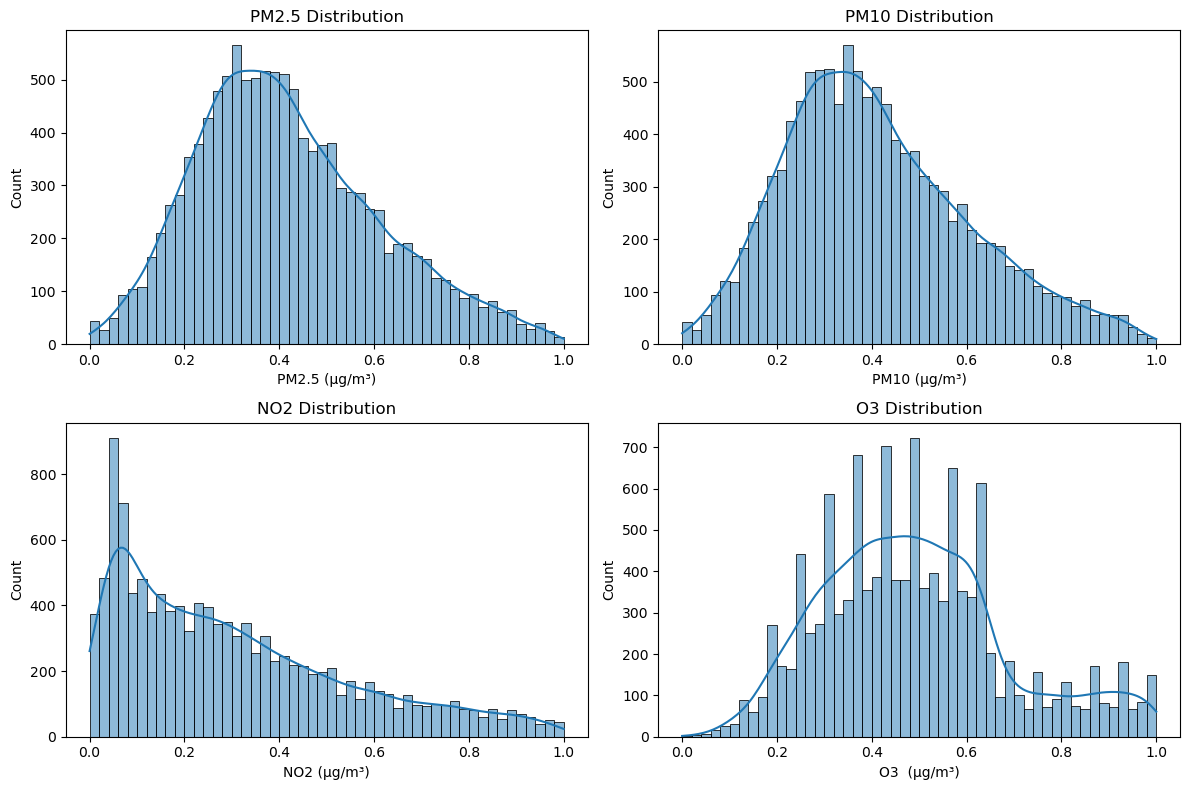

In [16]:
# Distribution of Key Pollutants
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['PM2.5 (μg/m³)'], bins=50, kde=True, ax=axes[0,0]).set(title="PM2.5 Distribution")
sns.histplot(df['PM10 (μg/m³)'], bins=50, kde=True, ax=axes[0,1]).set(title="PM10 Distribution")
sns.histplot(df['NO2 (μg/m³)'], bins=50, kde=True, ax=axes[1,0]).set(title="NO2 Distribution")
sns.histplot(df['O3  (μg/m³)'], bins=50, kde=True, ax=axes[1,1]).set(title="O3 Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/pollutant_distributions.png")
plt.show()

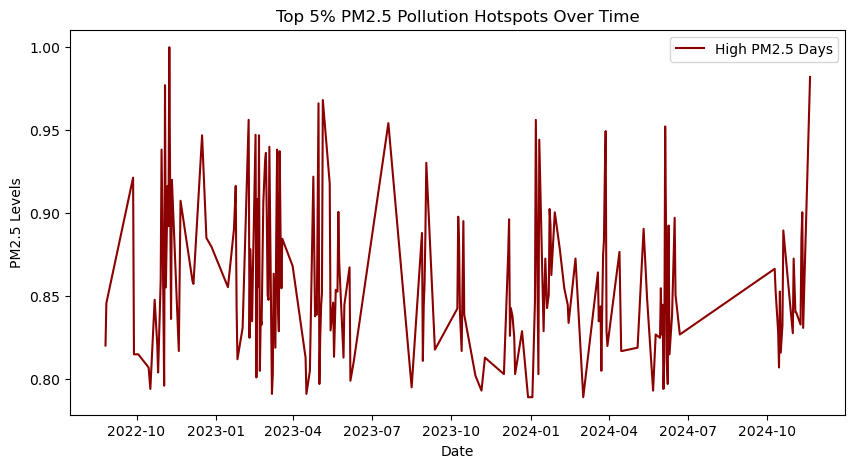

In [17]:

#Identify Pollution Hotspots
high_pm25 = df[df['PM2.5 (μg/m³)'] > df['PM2.5 (μg/m³)'].quantile(0.95)]
stats_hotspots = high_pm25.groupby(high_pm25.index.date).mean()
plt.figure(figsize=(10,5))
plt.plot(stats_hotspots.index, stats_hotspots['PM2.5 (μg/m³)'], label='High PM2.5 Days', color='darkred')
plt.xlabel("Date")
plt.ylabel("PM2.5 Levels")
plt.title("Top 5% PM2.5 Pollution Hotspots Over Time")
plt.legend()
plt.savefig("../reports/figures/pm25_hotspots.png")
plt.show()

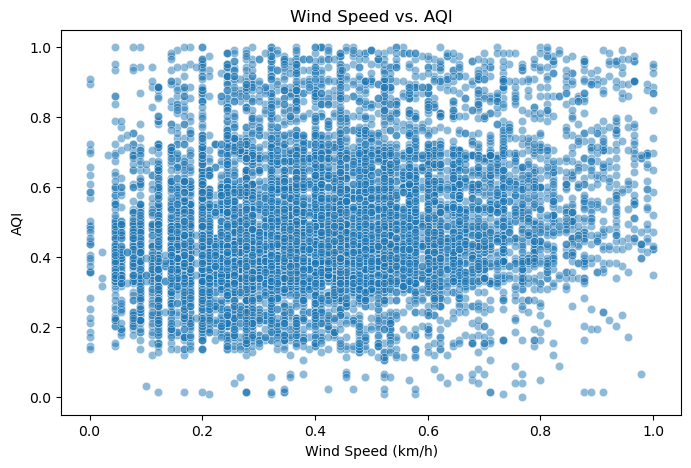

In [18]:

# Step 7: Wind Speed vs. AQI (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Wind_Speed (km/h)'], y=df['AQI'], alpha=0.5)
plt.title("Wind Speed vs. AQI")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("AQI")
plt.savefig("../reports/figures/wind_speed_aqi.png")
plt.show()